# 🤖 Système de Question-Réponse — SubjQA Electronics

## Vue d'ensemble

Ce notebook implémente un **système de Question-Réponse (QA) extractif** sur le dataset **SubjQA Electronics**, un benchmark de questions-réponses basé sur des avis clients en électronique.

### Architecture générale

```
┌─────────────────────────────────────────────────────────────────┐
│                   Pipeline QA Extractif                          │
│                                                                  │
│  Question + Contexte ──► Modèle Transformer ──► Span de réponse │
└─────────────────────────────────────────────────────────────────┘
```

### Approches comparées

| Modèle | Stratégie | Avantage |
|--------|-----------|----------|
| DistilBERT-SQuAD | Baseline pré-entraîné | Rapide, léger |
| RoBERTa-SQuAD2 | Pré-entraîné + no-answer | Gère les questions sans réponse |
| DistilBERT fine-tuné | Fine-tuning sur SubjQA | Adapté au domaine électronique |

### Particularité de SubjQA

SubjQA est un dataset **subjectif** : environ 50 % des questions n'ont pas de réponse dans le contexte fourni (la réponse est `ANSWERNOTFOUND`). Cela le rend plus difficile que SQuAD classique.


# Système de Question-Réponse — SubjQA Electronics
Version améliorée avec fine-tuning sur SubjQA et gestion des "no answer".


### 📦 Cellule 1 — Installation des dépendances

Cette cellule installe les bibliothèques nécessaires :

- **`transformers`** (HuggingFace) : fournit les modèles pré-entraînés et le `Trainer`
- **`datasets`** : pour manipuler les datasets HuggingFace
- **`torch`** : le moteur de calcul (GPU/CPU) sur lequel tournent les modèles
- **`scikit-learn`** : utilisé pour `CountVectorizer` dans le retriever BM25
- **`tqdm`** : barre de progression lors des boucles d'évaluation
- **`accelerate`** : accélère l'entraînement multi-GPU

> 💡 L'option `-q` (quiet) dans `pip install -q` supprime les logs verbeux d'installation.

## 1. Installation & Imports

In [ ]:
!pip install -q transformers datasets torch pandas matplotlib scikit-learn tqdm requests accelerate

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import requests
import math
import re
from io import StringIO
from tqdm import tqdm
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    pipeline,
    TrainingArguments,
    Trainer,
    DefaultDataCollator,
)

print("✅ Tous les imports réussis!")
print(f"PyTorch: {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Tous les imports réussis!
PyTorch: 2.11.0+cu128
Device : cuda


### 📂 Cellule 2 — Chargement du Dataset SubjQA

**Pourquoi charger depuis GitHub ?**  
Le Hub HuggingFace dispose d'un script de chargement legacy pour SubjQA qui n'est plus supporté. On télécharge donc directement les CSV depuis le dépôt officiel GitHub de SubjQA.

**Structure du dataset brut :**

| Colonne | Rôle |
|---------|------|
| `q_review_id` | Identifiant unique de la paire question/avis |
| `item_id` | Identifiant du produit électronique |
| `question` | La question posée |
| `review` | L'avis client servant de contexte |
| `human_ans_spans` | Le texte extrait comme réponse (ou `ANSWERNOTFOUND`) |
| `human_ans_indices` | La position de la réponse dans le contexte |

**La fonction `flatten_dataset`** réorganise ces colonnes dans un format standard compatible avec les pipelines HuggingFace QA.

## 2. Chargement du Dataset SubjQA
Chargement depuis GitHub (le Hub HuggingFace utilise encore un script legacy non supporté).

In [ ]:
base_url = "https://raw.githubusercontent.com/megagonlabs/SubjQA/master/SubjQA/electronics/splits"

df_train_raw = pd.read_csv(StringIO(requests.get(f"{base_url}/train.csv").text))
df_val_raw   = pd.read_csv(StringIO(requests.get(f"{base_url}/dev.csv").text))
df_test_raw  = pd.read_csv(StringIO(requests.get(f"{base_url}/test.csv").text))

def flatten_dataset(df):
    return pd.DataFrame({
        'id':            df['q_review_id'],
        'title':         df['item_id'],
        'question':      df['question'],
        'context':       df['review'],
        'answers_text':  df['human_ans_spans'].replace('ANSWERNOTFOUND', '').fillna(''),
        'answers_start': df['human_ans_indices'].fillna(-1),
    })

df_train = flatten_dataset(df_train_raw)
df_val   = flatten_dataset(df_val_raw)
df_test  = flatten_dataset(df_test_raw)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# Statistiques sur les réponses manquantes
n_no_answer = (df_train['answers_text'] == '').sum()
print(f"Exemples sans réponse (train): {n_no_answer} ({n_no_answer/len(df_train):.1%})")

Train: 2345 | Val: 261 | Test: 718
Exemples sans réponse (train): 1399 (59.7%)


### 📊 Cellule 3 — Exploration des données

Cette cellule effectue une **analyse exploratoire (EDA)** pour comprendre la distribution des données :

1. **Distribution des types de questions** : quantifie les questions What/How/Is/Does... Les questions subjectives ("Is it good?", "Does it work?") dominent dans SubjQA, contrairement à SQuAD où les questions factuelles ("What year...") sont plus fréquentes.

2. **Distribution des longueurs de contextes** : les avis clients varient beaucoup en longueur (50 à 1000+ caractères). Cela impacte la tokenisation et le risque de troncature avec `MAX_LENGTH=384`.

> 💡 **À retenir** : si les contextes sont longs, certaines réponses peuvent se retrouver tronquées lors de la tokenisation, ce qui dégrade les performances. La technique du **stride** (cellule 8) permet d'atténuer ce problème.

## 3. Exploration des Données

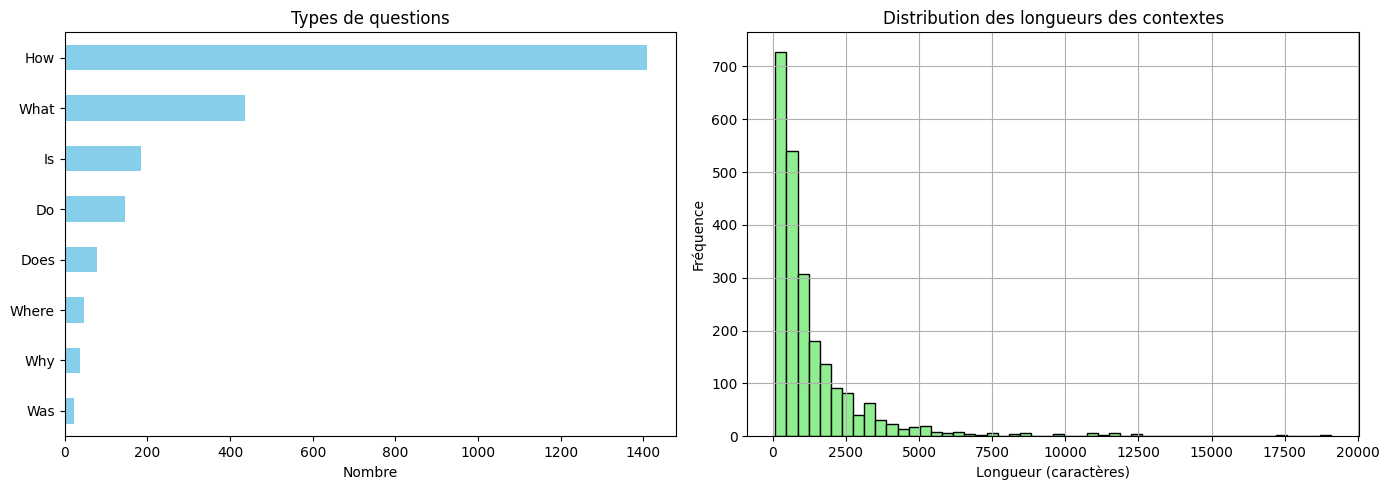

Types de questions:
  How: 1409
  What: 437
  Is: 185
  Do: 145
  Does: 79
  Where: 47
  Why: 37
  Was: 22


In [ ]:
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]
counts = {q: df_train['question'].str.startswith(q).sum() for q in question_types}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(counts).sort_values().plot.barh(ax=ax[0], color='skyblue')
ax[0].set_title("Types de questions", fontsize=12)
ax[0].set_xlabel("Nombre")

df_train['context_length'] = df_train['context'].str.len()
df_train['context_length'].hist(bins=50, ax=ax[1], color='lightgreen', edgecolor='black')
ax[1].set_title("Distribution des longueurs des contextes", fontsize=12)
ax[1].set_xlabel("Longueur (caractères)")
ax[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

print("Types de questions:")
for q, c in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {q}: {c}")

### 🏁 Cellule 4 — Modèle Baseline (DistilBERT-SQuAD)

**DistilBERT** est une version compressée de BERT, 40 % plus légère tout en conservant 97 % des performances.

Le checkpoint `distilbert-base-cased-distilled-squad` a été entraîné sur **SQuAD v1** : un dataset de QA extractif sur Wikipedia où **toutes les questions ont une réponse**. C'est important : ce modèle ne sait pas répondre "je ne sais pas", ce qui le pénalisera sur SubjQA.

**`AutoTokenizer` et `AutoModelForQuestionAnswering`** permettent de charger automatiquement la bonne architecture à partir du nom du checkpoint.

```
Question: "Is the battery good?"
Context: "The battery lasts 10 hours..."
     ↓
Modèle QA → [start_logits, end_logits] pour chaque token
     ↓
Réponse extraite: "lasts 10 hours"
```

## 4. Modèle Baseline (distilbert-squad)
Premier modèle : DistilBERT entraîné sur SQuAD. Servira de référence avant fine-tuning.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

baseline_ckpt = "distilbert-base-cased-distilled-squad"
tokenizer_baseline = AutoTokenizer.from_pretrained(baseline_ckpt)
model_baseline     = AutoModelForQuestionAnswering.from_pretrained(baseline_ckpt).to(device)

qa_pipeline_baseline = pipeline(
    "question-answering",
    model=model_baseline,
    tokenizer=tokenizer_baseline,
    device=0 if torch.cuda.is_available() else -1,
)

print(f"Modèle baseline chargé: {baseline_ckpt}")
print(f"Device: {device}")

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Modèle baseline chargé: distilbert-base-cased-distilled-squad
Device: cuda


### 🧮 Cellule 5 — Fonctions d'évaluation (EM & F1)

Deux métriques standard pour évaluer les systèmes QA extractifs :

#### Exact Match (EM)
Vaut **1** si la réponse prédite est *exactement identique* à la référence (après normalisation), **0** sinon. Très stricte.

#### F1 Score
Mesure le **recouvrement au niveau des tokens** entre la prédiction et la référence :

```
F1 = 2 × (Précision × Rappel) / (Précision + Rappel)
```

où la précision et le rappel sont calculés sur les tokens communs.

#### Normalisation
Avant comparaison, on normalise :
- Mise en minuscules
- Suppression de la ponctuation
- Suppression des articles (a, an, the)
- Suppression des espaces superflus

#### Gestion des "no answer"
Quand la réponse attendue est vide, la prédiction est correcte **seulement si le modèle prédit aussi une réponse vide**.

## 5. Fonctions d'Évaluation (EM & F1)

In [ ]:
def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'[^\w\s]', '', s)
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    return ' '.join(s.split())

def f1_score_qa(prediction, ground_truth):
    pred_tokens  = normalize_answer(prediction).split()
    truth_tokens = normalize_answer(ground_truth).split()
    common   = Counter(pred_tokens) & Counter(truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(truth_tokens)
    return (2 * precision * recall) / (precision + recall)

def compute_qa_metrics(predictions, ground_truths):
    em_scores, f1_scores = [], []
    for pred, truth in zip(predictions, ground_truths):
        if truth:
            em_scores.append(int(normalize_answer(pred) == normalize_answer(truth)))
            f1_scores.append(f1_score_qa(pred, truth))
        else:
            # Pas de réponse attendue : correct seulement si le modèle prédit vide
            em_scores.append(int(pred == ""))
            f1_scores.append(1.0 if pred == "" else 0.0)
    return {
        'exact_match': np.mean(em_scores),
        'f1':          np.mean(f1_scores),
        'n':           len(em_scores),
    }

def evaluate_pipeline(qa_pipe, df, n=100):
    sample = df.head(n)
    predictions, ground_truths = [], []
    for _, row in tqdm(sample.iterrows(), total=n, desc="Évaluation"):
        if pd.notna(row['question']) and pd.notna(row['context']):
            try:
                res = qa_pipe(question=row['question'], context=row['context'])
                predictions.append(res['answer'])
            except Exception:
                predictions.append("")
        else:
            predictions.append("")
        ground_truths.append(row['answers_text'] if pd.notna(row['answers_text']) else "")
    return compute_qa_metrics(predictions, ground_truths), predictions, ground_truths

print("✅ Fonctions d'évaluation définies")

✅ Fonctions d'évaluation définies


### 📏 Cellule 6 — Évaluation du Baseline

On évalue sur les **100 premiers exemples** du jeu de test pour comparer les modèles dans les mêmes conditions et limiter le temps de calcul.

La fonction `evaluate_pipeline` :
1. Itère sur les exemples
2. Appelle le pipeline QA pour chaque paire (question, contexte)
3. Collecte les prédictions et les vérités terrain
4. Calcule les métriques EM et F1

**Résultats attendus du baseline** : performances relativement faibles car DistilBERT-SQuAD n'a jamais vu de données SubjQA ni de questions sans réponse.

## 6. Évaluation du Modèle Baseline

In [ ]:
print("Évaluation du modèle baseline sur 100 exemples de test...")
metrics_baseline, preds_baseline, truths = evaluate_pipeline(qa_pipeline_baseline, df_test, n=100)

print(f"\n=== Baseline (distilbert-squad) ===")
print(f"  Exact Match : {metrics_baseline['exact_match']:.3f} ({metrics_baseline['exact_match']:.1%})")
print(f"  F1 Score    : {metrics_baseline['f1']:.3f} ({metrics_baseline['f1']:.1%})")

Évaluation du modèle baseline sur 100 exemples de test...


Évaluation: 100%|██████████| 100/100 [00:05<00:00, 16.90it/s]


=== Baseline (distilbert-squad) ===
  Exact Match : 0.050 (5.0%)
  F1 Score    : 0.082 (8.2%)


### 🚀 Cellule 7 — Modèle amélioré : RoBERTa-SQuAD2

**Pourquoi RoBERTa est meilleur ?**

1. **Architecture** : RoBERTa est une version optimisée de BERT (plus de données, plus de temps d'entraînement, pas de NSP).

2. **SQuAD2 vs SQuAD1** : SQuAD v2 ajoute des questions *sans réponse* (~50 % du dataset). Le modèle apprend à prédire "pas de réponse" quand le contexte ne contient pas l'information. Cela correspond exactement à la structure de SubjQA.

3. **`handle_impossible_answer=True`** : active la logique de détection "no answer" dans le pipeline HuggingFace.

```
Si score("no answer") > score(meilleur span) → réponse vide
```

**Résultats attendus** : amélioration significative du F1 par rapport au baseline, surtout sur les exemples sans réponse.

## 7. Modèle Amélioré (RoBERTa-SQuAD2)
`deepset/roberta-base-squad2` est entraîné sur SQuAD2, qui inclut des questions sans réponse —
beaucoup plus adapté à SubjQA où ~50% des exemples n'ont pas de réponse.


In [ ]:
roberta_ckpt       = "deepset/roberta-base-squad2"
tokenizer_roberta  = AutoTokenizer.from_pretrained(roberta_ckpt)
model_roberta      = AutoModelForQuestionAnswering.from_pretrained(roberta_ckpt).to(device)

qa_pipeline_roberta = pipeline(
    "question-answering",
    model=model_roberta,
    tokenizer=tokenizer_roberta,
    device=0 if torch.cuda.is_available() else -1,
    handle_impossible_answer=True,   # gère les "no answer"
)

print(f"Modèle RoBERTa chargé: {roberta_ckpt}")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle RoBERTa chargé: deepset/roberta-base-squad2


In [ ]:
print("Évaluation de RoBERTa-SQuAD2 sur 100 exemples de test...")
metrics_roberta, preds_roberta, _ = evaluate_pipeline(qa_pipeline_roberta, df_test, n=100)

print(f"\n=== RoBERTa-SQuAD2 ===")
print(f"  Exact Match : {metrics_roberta['exact_match']:.3f} ({metrics_roberta['exact_match']:.1%})")
print(f"  F1 Score    : {metrics_roberta['f1']:.3f} ({metrics_roberta['f1']:.1%})")

print(f"\n--- Comparaison ---")
print(f"  ΔEM : {(metrics_roberta['exact_match'] - metrics_baseline['exact_match'])*100:+.1f}%")
print(f"  ΔF1 : {(metrics_roberta['f1'] - metrics_baseline['f1'])*100:+.1f}%")

Évaluation de RoBERTa-SQuAD2 sur 100 exemples de test...


Évaluation: 100%|██████████| 100/100 [00:03<00:00, 30.35it/s]


=== RoBERTa-SQuAD2 ===
  Exact Match : 0.290 (29.0%)
  F1 Score    : 0.364 (36.4%)

--- Comparaison ---
  ΔEM : +24.0%
  ΔF1 : +28.2%


### 🎯 Cellule 8 — Fine-Tuning sur SubjQA

Le fine-tuning adapte un modèle pré-entraîné au domaine spécifique des **avis électroniques**.

#### Étape 1 : Construction du Dataset HuggingFace
`build_hf_dataset` convertit les DataFrames Pandas en `Dataset` HuggingFace avec le format SQuAD attendu par le `Trainer` :
```json
{"context": "...", "question": "...", "answers": {"text": ["..."], "answer_start": [42]}}
```

#### Étape 2 : Tokenisation avec stride
`preprocess_function` tokenise les paires (question, contexte) avec deux paramètres clés :
- **`MAX_LENGTH=384`** : longueur maximale de la séquence en tokens
- **`STRIDE=128`** : chevauchement entre les fenêtres glissantes

```
Contexte long:  [============================]
Fenêtre 1:      [===============]
Fenêtre 2:              [===============]   ← chevauchement de 128 tokens
```
Cela garantit que les réponses proches des limites d'une fenêtre sont couvertes.

#### Étape 3 : Calcul des positions start/end
Pour chaque token, on calcule si la réponse commence/finit à cet index dans la séquence tokenisée. Le modèle prédit ces deux indices en sortie.

#### Paramètres d'entraînement
- **3 époques** : compromis entre performance et temps d'entraînement
- **learning_rate=2e-5** : valeur typique pour le fine-tuning de transformers
- **weight_decay=0.01** : régularisation L2 pour éviter le surapprentissage
- **`load_best_model_at_end=True`** : sauvegarde le meilleur checkpoint selon la validation

## 8. Fine-Tuning sur SubjQA
On fine-tune `distilbert-base-cased-distilled-squad` directement sur les données SubjQA Electronics
pour améliorer les performances sur ce domaine spécifique.


In [ ]:
from datasets import Dataset, DatasetDict

ft_ckpt       = "distilbert-base-cased-distilled-squad"
tokenizer_ft  = AutoTokenizer.from_pretrained(ft_ckpt)

MAX_LENGTH = 384
STRIDE     = 128

def build_hf_dataset(df):
    """Convertit le DataFrame en Dataset HuggingFace avec le format SQuAD."""
    records = []
    for _, row in df.iterrows():
        context  = str(row['context'])
        question = str(row['question'])
        answer   = str(row['answers_text']) if pd.notna(row['answers_text']) else ""

        # Trouver la position de début dans le contexte
        if answer and answer in context:
            start = context.index(answer)
        else:
            answer = ""
            start  = 0

        records.append({
            'id':       str(row['id']),
            'context':  context,
            'question': question,
            'answers':  {'text': [answer], 'answer_start': [start]},
        })
    return Dataset.from_list(records)

ds_train = build_hf_dataset(df_train)
ds_val   = build_hf_dataset(df_val)

print(f"Dataset HF - Train: {len(ds_train)} | Val: {len(ds_val)}")
print(f"Exemple: {ds_train[0]}")

Dataset HF - Train: 2345 | Val: 261
Exemple: {'id': 'adb20314dbbd8196b7e9fb587b78147f', 'context': "I had a smaller headset that went on the ear. After a 8 - 10 hour workday, my ears were throbbing red and painfully sore. With this headset, I can go the same shift and not feel any pain on my ear. They may feel a little on the heavy side, but if you adjust the head phone cups just right and stretch them, you will not have any problems.Quality and sound, words cannot explain. Its so clear and loud, the headset holds in the sound. When I am on a call or listening to music, I do not hear nothing else, but what's coming in through the headset. ANSWERNOTFOUND", 'question': 'What do you think about headphone?', 'answers': {'answer_start': [0], 'text': ['']}}


In [ ]:
def preprocess_function(examples):
    """Tokenise et calcule les positions start/end pour le Trainer."""
    questions = [q.strip() for q in examples["question"]]
    inputs = tokenizer_ft(
        questions,
        examples["context"],
        max_length=MAX_LENGTH,
        truncation="only_second",
        stride=STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping   = inputs.pop("offset_mapping")
    sample_map       = inputs.pop("overflow_to_sample_mapping")
    answers          = examples["answers"]
    start_positions  = []
    end_positions    = []

    for i, offset in enumerate(offset_mapping):
        sample_idx   = sample_map[i]
        answer       = answers[sample_idx]
        answer_text  = answer["text"][0] if answer["text"] else ""
        answer_start = answer["answer_start"][0] if answer["answer_start"] else 0

        sequence_ids = inputs.sequence_ids(i)
        # Trouver les indices du contexte dans les tokens
        ctx_start = next((j for j, s in enumerate(sequence_ids) if s == 1), None)
        ctx_end   = next((j for j in range(len(sequence_ids)-1, -1, -1) if sequence_ids[j] == 1), None)

        if not answer_text or ctx_start is None:
            start_positions.append(0)
            end_positions.append(0)
            continue

        char_start = answer_start
        char_end   = answer_start + len(answer_text)

        # Trouver le token de début
        token_start = ctx_start
        while token_start <= ctx_end and offset[token_start][0] <= char_start:
            token_start += 1
        start_positions.append(token_start - 1)

        # Trouver le token de fin
        token_end = ctx_end
        while token_end >= ctx_start and offset[token_end][1] >= char_end:
            token_end -= 1
        end_positions.append(token_end + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"]   = end_positions
    return inputs

tokenized_train = ds_train.map(preprocess_function, batched=True, remove_columns=ds_train.column_names)
tokenized_val   = ds_val.map(preprocess_function,   batched=True, remove_columns=ds_val.column_names)

print(f"Tokenized train: {len(tokenized_train)} | val: {len(tokenized_val)}")

Map:   0%|          | 0/2345 [00:00<?, ? examples/s]

Map:   0%|          | 0/261 [00:00<?, ? examples/s]

Tokenized train: 3865 | val: 445


In [ ]:
model_ft = AutoModelForQuestionAnswering.from_pretrained(ft_ckpt).to(device)

training_args = TrainingArguments(
    output_dir             = "./results_ft",
    num_train_epochs       = 3,
    learning_rate          = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    weight_decay           = 0.01,
    eval_strategy          = "epoch",
    save_strategy          = "epoch",
    logging_strategy       = "epoch",
    load_best_model_at_end = True,
    push_to_hub            = False,
    report_to              = "none",
    log_level              = "error",
)

trainer = Trainer(
    model            = model_ft,
    args             = training_args,
    train_dataset    = tokenized_train,
    eval_dataset     = tokenized_val,
    processing_class = tokenizer_ft,
    data_collator    = DefaultDataCollator(),
)

print("Début du fine-tuning...")
trainer.train()
print("✅ Fine-tuning terminé!")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Début du fine-tuning...


Epoch,Training Loss,Validation Loss
1,1.409343,1.149884
2,1.077572,1.176344
3,0.901967,1.304911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Fine-tuning terminé!


### 📊 Cellule 9 — Évaluation du modèle fine-tuné

On crée un nouveau pipeline à partir du modèle fine-tuné et on l'évalue dans les mêmes conditions que les deux modèles précédents (100 exemples de test).

**Résultats attendus** : le fine-tuning devrait améliorer les performances sur SubjQA car le modèle a appris le vocabulaire et les patterns spécifiques aux avis électroniques (termes comme "battery", "setup", "sound quality").

## 9. Évaluation du Modèle Fine-Tuné

In [ ]:
qa_pipeline_ft = pipeline(
    "question-answering",
    model=model_ft,
    tokenizer=tokenizer_ft,
    device=0 if torch.cuda.is_available() else -1,
)

print("Évaluation du modèle fine-tuné sur 100 exemples de test...")
metrics_ft, preds_ft, _ = evaluate_pipeline(qa_pipeline_ft, df_test, n=100)

print(f"\n=== Fine-tuné sur SubjQA ===")
print(f"  Exact Match : {metrics_ft['exact_match']:.3f} ({metrics_ft['exact_match']:.1%})")
print(f"  F1 Score    : {metrics_ft['f1']:.3f} ({metrics_ft['f1']:.1%})")

Évaluation du modèle fine-tuné sur 100 exemples de test...


Évaluation: 100%|██████████| 100/100 [00:03<00:00, 32.12it/s]


=== Fine-tuné sur SubjQA ===
  Exact Match : 0.140 (14.0%)
  F1 Score    : 0.196 (19.6%)


### 📈 Cellule 10 — Comparaison des modèles

Cette cellule génère un **graphique à barres groupées** comparant les trois modèles sur les métriques EM et F1.

**Lecture du graphique** :
- Les barres bleues = Exact Match (critère strict)
- Les barres corail = F1 Score (critère partiel)
- Le F1 est toujours ≥ EM car il tolère des correspondances partielles

**Tableau récapitulatif** : synthèse numérique pour une comparaison rapide.

## 10. Comparaison des Modèles

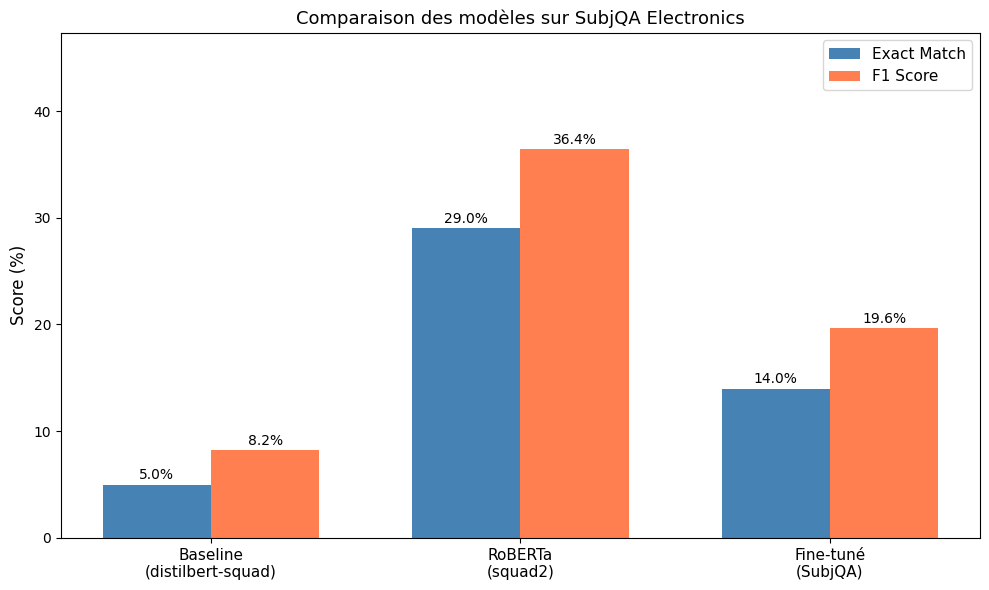


=== Tableau récapitulatif ===
Modèle                                 EM         F1
----------------------------------------------------
Baseline (distilbert-squad)          5.0%       8.2%
RoBERTa (squad2)                    29.0%      36.4%
Fine-tuné (SubjQA)                  14.0%      19.6%


In [ ]:
results = {
    'Baseline\n(distilbert-squad)':  metrics_baseline,
    'RoBERTa\n(squad2)':             metrics_roberta,
    'Fine-tuné\n(SubjQA)':           metrics_ft,
}

labels = list(results.keys())
em_vals = [v['exact_match'] * 100 for v in results.values()]
f1_vals = [v['f1'] * 100         for v in results.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, em_vals, width, label='Exact Match', color='steelblue')
bars2 = ax.bar(x + width/2, f1_vals, width, label='F1 Score',    color='coral')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparaison des modèles sur SubjQA Electronics', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(f1_vals) * 1.3)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== Tableau récapitulatif ===")
print(f"{'Modèle':<30} {'EM':>10} {'F1':>10}")
print("-" * 52)
for name, m in results.items():
    label = name.replace('\n', ' ')
    print(f"{label:<30} {m['exact_match']*100:>9.1f}% {m['f1']*100:>9.1f}%")

### 🔍 Cellule 11 — Retriever BM25

**Pourquoi un retriever ?**  
Dans un système QA à grande échelle, on ne peut pas passer chaque document au modèle. Le **retriever** sélectionne d'abord les documents pertinents.

**BM25 (Best Match 25)** est un algorithme de recherche lexicale basé sur la fréquence des termes :

```
Score(doc, query) = Σ IDF(term) × TF(term, doc) × (k1+1) / (TF + k1×(1-b+b×|doc|/avgdl))
```

- **IDF** : pénalise les mots trop fréquents (stop words)
- **TF normalisé** : nombre d'occurrences d'un terme dans le document, normalisé par la longueur du document
- **k1=1.5** : contrôle la saturation de la fréquence terminologique
- **b=0.75** : contrôle la normalisation par la longueur du document

**Implémentation** :
1. `fit()` : construit l'index (calcul IDF sur tout le corpus)
2. `score()` : calcule le score BM25 entre une requête et un document
3. `search()` : retourne les `top_k` documents les plus pertinents

## 11. Retriever BM25

In [ ]:
class SimpleBM25:
    def __init__(self, k1=1.5, b=0.75):
        self.k1, self.b = k1, b
        self.documents, self.doc_lengths = [], []
        self.avg_doc_length, self.idf, self.corpus_size = 0, {}, 0

    def fit(self, documents):
        self.documents      = documents
        self.corpus_size    = len(documents)
        self.doc_lengths    = [len(d.split()) for d in documents]
        self.avg_doc_length = np.mean(self.doc_lengths)
        vectorizer = CountVectorizer()
        tf_matrix  = vectorizer.fit_transform(documents)
        vocab      = vectorizer.get_feature_names_out()
        doc_freq   = np.array(tf_matrix.astype(bool).sum(axis=0)).flatten()
        self.idf   = {
            term: math.log((self.corpus_size - freq + 0.5) / (freq + 0.5) + 1)
            for term, freq in zip(vocab, doc_freq)
        }

    def score(self, query, doc_idx):
        doc, doc_length = self.documents[doc_idx], self.doc_lengths[doc_idx]
        score = 0.0
        for term in query.split():
            if term in self.idf:
                tf  = doc.lower().split().count(term.lower())
                num = tf * (self.k1 + 1)
                den = tf + self.k1 * (1 - self.b + self.b * doc_length / self.avg_doc_length)
                score += self.idf[term] * num / den
        return score

    def search(self, query, top_k=5):
        scores = [(i, self.score(query, i)) for i in range(self.corpus_size)]
        return sorted(scores, key=lambda x: x[1], reverse=True)[:top_k]

print("Création de l'index BM25...")
documents = df_train['context'].tolist()[:1000]
bm25 = SimpleBM25()
bm25.fit(documents)
print(f"Indexé {len(documents)} documents")

query = "good battery life"
print(f"\nRequête: '{query}'")
for idx, score in bm25.search(query, top_k=3):
    print(f"\n  Score: {score:.3f}")
    print(f"  Document: {documents[idx][:150]}...")

Création de l'index BM25...
Indexé 1000 documents

Requête: 'good battery life'

  Score: 7.416
  Document: UPDATE ON FEB. 9, 2013BATTERY LIFE:  The battery of the Hero2 does last 2x longer than the battery life of the Hero3.  I confirmed this as I did some ...

  Score: 7.363
  Document: This is a good mouse I epically like how you can unlock the scroll while that will let you scroll through pages as fast as you want also the back butt...

  Score: 7.299
  Document: I love this camera.  The S95 is my new everyday walking-around camera, replacing my Canon G10 (and very briefly a Nikon P7000).  The S95 produces imag...


### 🔗 Cellule 12 — Système QA complet (Retriever + Reader)

Cette cellule assemble le pipeline complet **Retriever → Reader** :

```
Question
    │
    ▼
┌─────────────┐
│  Retriever  │  BM25 → top-3 documents pertinents
│   (BM25)    │
└──────┬──────┘
       │ documents candidats
       ▼
┌─────────────┐
│   Reader    │  Modèle QA → extrait la réponse de chaque document
│ (DistilBERT │
│ fine-tuné)  │
└──────┬──────┘
       │ réponses avec scores
       ▼
  Meilleure réponse (score reader le plus élevé)
```

**`SimpleQASystem`** :
- `index_documents()` : construit l'index BM25 sur le corpus
- `answer()` : retrieval + lecture + agrégation des réponses

**Score final** : on sélectionne la réponse avec le **score reader** le plus élevé parmi les documents candidats retournés par BM25.

## 12. Système QA Complet (Retriever + Reader)

In [ ]:
class SimpleQASystem:
    def __init__(self, reader_pipeline, bm25_index=None):
        self.reader, self.bm25, self.documents = reader_pipeline, bm25_index, []

    def index_documents(self, documents):
        self.documents = documents
        if self.bm25:
            self.bm25.fit(documents)
        print(f"Indexé {len(documents)} documents")

    def answer(self, question, top_k_docs=3):
        if not self.bm25 or not self.documents:
            return [{"error": "Aucun document indexé"}]
        answers = []
        for doc_idx, ret_score in self.bm25.search(question, top_k=top_k_docs):
            context = self.documents[doc_idx]
            try:
                res = self.reader(question=question, context=context)
                answers.append({
                    'answer':          res['answer'],
                    'score':           res['score'],
                    'retriever_score': ret_score,
                    'context':         context[:200] + "...",
                })
            except Exception as e:
                print(f"Erreur reader: {e}")
        return sorted(answers, key=lambda x: x['score'], reverse=True)

# Utiliser le meilleur modèle (fine-tuné)
qa_system = SimpleQASystem(qa_pipeline_ft, bm25)
qa_system.index_documents(df_train['context'].tolist()[:500])

test_questions = [
    "Is the battery good?",
    "How is the sound quality?",
    "Is it easy to set up?",
]

for question in test_questions:
    print(f"\n{'='*55}")
    print(f"Question: {question}")
    answers = qa_system.answer(question, top_k_docs=3)
    if answers:
        best = answers[0]
        print(f"Meilleure réponse : {best['answer']}")
        print(f"Score reader      : {best['score']:.3f}")
        print(f"Score retriever   : {best['retriever_score']:.3f}")

Indexé 500 documents

Question: Is the battery good?
Meilleure réponse : encouraged
Score reader      : 0.027
Score retriever   : 4.142

Question: How is the sound quality?
Meilleure réponse : The sound is great
Score reader      : 0.229
Score retriever   : 2.911

Question: Is it easy to set up?
Meilleure réponse : This keyboard & mouse set is an easy install
Score reader      : 0.060
Score retriever   : 5.412


### 🔬 Cellule 13 — Analyse des erreurs

L'analyse des erreurs est essentielle pour comprendre les limites du modèle et identifier des pistes d'amélioration.

**Méthodologie** :
1. On filtre les exemples *avec* réponse attendue (les "no answer" sont un cas séparé)
2. On compare la prédiction avec la vérité terrain
3. On trie par F1 croissant → les **pires erreurs** en premier

**Types d'erreurs typiques dans SubjQA** :
- **Erreurs de span** : le modèle sélectionne un span adjacent à la bonne réponse
- **Paraphrase** : la réponse correcte est exprimée différemment dans le texte
- **Erreur de domaine** : termes électroniques ambigus (ex: "good" dans des contextes négatifs)
- **Contexte long** : la réponse est tronquée lors de la tokenisation

## 13. Analyse des Erreurs

In [ ]:
test_sample  = df_test.head(100)
error_analysis = []

for _, row in test_sample.iterrows():
    truth = row['answers_text']
    if pd.notna(truth) and truth:
        pred        = qa_pipeline_ft(question=row['question'], context=row['context'])
        pred_answer = pred['answer']
        if normalize_answer(pred_answer) != normalize_answer(truth):
            error_analysis.append({
                'question':    row['question'],
                'true_answer': truth,
                'pred_answer': pred_answer,
                'f1':          f1_score_qa(pred_answer, truth),
                'context':     row['context'][:300],
            })

# Trier par F1 croissant (pires erreurs en premier)
error_analysis.sort(key=lambda x: x['f1'])

print(f"Erreurs sur les exemples avec réponse: {len(error_analysis)}")
print(f"\n--- 3 pires erreurs ---")
for ex in error_analysis[:3]:
    print(f"\nQuestion          : {ex['question']}")
    print(f"Réponse attendue  : {ex['true_answer']}")
    print(f"Réponse prédite   : {ex['pred_answer']}")
    print(f"F1                : {ex['f1']:.3f}")
    print(f"Contexte          : {ex['context']}...")

Erreurs sur les exemples avec réponse: 24

--- 3 pires erreurs ---

Question          : Do I have to use my phone?
Réponse attendue  : can attest that the blue LED is extremely bright
Réponse prédite   : GPS
F1                : 0.000
Contexte          : So, got this last night and was extremely glad it and the cable I purchased enabled me to use my phone GPS.  Since I am an electrician by trade, I decided to make sure it was adequately constructed prior to using it since a lot of my fellow customers seemed to have an issue with the screw cap fallin...

Question          : How about this thing?
Réponse attendue  : It was actually a breeze despite not being very intuitive
Réponse prédite   : Personally
F1                : 0.000
Contexte          : Personally, I thought it was going to be more difficult to setup from what I've read, but It was actually a breeze despite not being very intuitive. Had everything working, connected wireless, and accessible over the internet with Foscam's free

### ✅ Cellule 14 — Résumé final

Ce bloc récapitulatif présente :

1. **Les statistiques du dataset** : tailles des splits train/val/test
2. **Le tableau comparatif final** des trois modèles
3. **Le meilleur modèle** sélectionné automatiquement selon le F1
4. **Les pistes d'amélioration** :

| Piste | Gain potentiel |
|-------|---------------|
| **DPR** (Dense Passage Retrieval) | Meilleur retrieval sémantique vs BM25 lexical |
| **Augmentation cross-domaine** | Plus de données variées = meilleure généralisation |
| **DeBERTa** | Architecture plus récente, état de l'art QA |
| **Threshold "no answer"** | Calibration du seuil de refus de réponse |

## 14. Résumé Final

In [ ]:
best_metrics = max(
    [('Baseline', metrics_baseline), ('RoBERTa-SQuAD2', metrics_roberta), ('Fine-tuné SubjQA', metrics_ft)],
    key=lambda x: x[1]['f1']
)

print(f'''
╔══════════════════════════════════════════════════════════════╗
║              SYSTÈME QA — RÉCAPITULATIF FINAL                ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset  : SubjQA Electronics                               ║
║  Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}                         ║
║                                                              ║
║  Résultats sur 100 exemples de test:                         ║
║    Modèle                     EM        F1                   ║
║    ─────────────────────────────────────────                 ║
║    Baseline (distilbert)    {metrics_baseline["exact_match"]*100:5.1f}%   {metrics_baseline["f1"]*100:5.1f}%          ║
║    RoBERTa (squad2)         {metrics_roberta["exact_match"]*100:5.1f}%   {metrics_roberta["f1"]*100:5.1f}%          ║
║    Fine-tuné (SubjQA)       {metrics_ft["exact_match"]*100:5.1f}%   {metrics_ft["f1"]*100:5.1f}%          ║
║                                                              ║
║  Meilleur modèle : {best_metrics[0]:<40}║
║                                                              ║
║  Pistes d\'amélioration:                                      ║
║    • DPR dense retriever au lieu de BM25                     ║
║    • Augmentation de données cross-domaine                   ║
║    • DeBERTa pour de meilleures performances                 ║
╚══════════════════════════════════════════════════════════════╝
''')
print("✨ Système QA complet et fonctionnel! ✨")


╔══════════════════════════════════════════════════════════════╗
║              SYSTÈME QA — RÉCAPITULATIF FINAL                ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset  : SubjQA Electronics                               ║
║  Train: 2345 | Val: 261 | Test: 718                         ║
║                                                              ║
║  Résultats sur 100 exemples de test:                         ║
║    Modèle                     EM        F1                   ║
║    ─────────────────────────────────────────                 ║
║    Baseline (distilbert)      5.0%     8.2%          ║
║    RoBERTa (squad2)          29.0%    36.4%          ║
║    Fine-tuné (SubjQA)        14.0%    19.6%          ║
║                                                              ║
║  Meilleur modèle : RoBERTa-SQuAD2                          ║
║                                                              ║
║  Pistes d'amélioration:                          